<h1 align="center">
<h1 align="center"> Recommendation System using AI/HCI Project


<h3 align="center"> Trey Williams

<h3 align="center"> University of the Cumberlands

<h3 align="center"> MSAI-631-A01: Artificial Intelligence for Human-Computer Interaction
    
<h3 align="center"> Dr. Alan Dennis

In [1]:
import pandas as pd
import numpy as np
import os

In [3]:
# Import Files

from google.colab import files

uploaded = files.upload()

Saving abilities_to_work_activities.csv to abilities_to_work_activities.csv
Saving abilities_to_work_context.csv to abilities_to_work_context.csv
Saving abilities.csv to abilities.csv
Saving career_interest_type_keywords.csv to career_interest_type_keywords.csv
Saving career_interest_types.csv to career_interest_types.csv
Saving content_model_reference.csv to content_model_reference.csv
Saving education_categories.csv to education_categories.csv
Saving education.csv to education.csv
Saving emerging_tasks.csv to emerging_tasks.csv
Saving essential_skills_to_work_activities.csv to essential_skills_to_work_activities.csv
Saving essential_skills_to_work_context.csv to essential_skills_to_work_context.csv
Saving essential_skills.csv to essential_skills.csv
Saving gwas_to_iwas_to_dwas.csv to gwas_to_iwas_to_dwas.csv
Saving gwas_to_iwas.csv to gwas_to_iwas.csv
Saving interests_illustrative_activities.csv to interests_illustrative_activities.csv
Saving interests_illustrative_occupations.csv to

In [4]:
# CHECK FILES IN COLAB RUNTIME

for file in sorted(os.listdir("/content")):
    print(file)

.config
Read Me.txt
abilities.csv
abilities_to_work_activities.csv
abilities_to_work_context.csv
career_interest_type_keywords.csv
career_interest_types.csv
content_model_reference.csv
education.csv
education_categories.csv
emerging_tasks.csv
essential_skills.csv
essential_skills_to_work_activities.csv
essential_skills_to_work_context.csv
gwas_to_iwas.csv
gwas_to_iwas_to_dwas.csv
interests_illustrative_activities.csv
interests_illustrative_occupations.csv
job_titles.csv
job_zone_reference.csv
job_zones.csv
knowledge.csv
level_scale_anchors.csv
occupation_data.csv
occupation_level_metadata.csv
related_occupations.csv
sample_data
sample_of_reported_titles.csv
scales_reference.csv
software_skills.csv
specific_interest_areas.csv
specific_interest_areas_to_career_interest_types.csv
survey_booklet_locations.csv
task_categories.csv
task_ratings.csv
task_statements.csv
tasks_to_dwas.csv
training_and_experience.csv
training_and_experience_categories.csv
transferable_skills.csv
transferable_skil

In [8]:
# LOAD OCCUPATION DATA

occupation_df = pd.read_csv("/content/occupation_data.csv")

print("Shape:", occupation_df.shape)
occupation_df.head()

Shape: (1016, 3)


,O*NET-SOC Code,Title,Description
0,11-1011.00,Chief Executives,Determine and formulate policies and provide o...
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh..."
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ..."
3,11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes..."
4,11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici..."


In [13]:
# Inspect Occupation Data

occupation_df.head()

,O*NET-SOC Code,Title,Description
0,11-1011.00,Chief Executives,Determine and formulate policies and provide o...
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh..."
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ..."
3,11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes..."
4,11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici..."


In [14]:
# LOAD CORE O*NET TABLES


education_df = pd.read_csv("/content/education.csv")
skills_df = pd.read_csv("/content/essential_skills.csv")
knowledge_df = pd.read_csv("/content/knowledge.csv")
abilities_df = pd.read_csv("/content/abilities.csv")
work_styles_df = pd.read_csv("/content/work_styles.csv")
experience_df = pd.read_csv("/content/training_and_experience.csv")

In [15]:
# INSPECT CORE TABLES

core_tables = {
    "education": education_df,
    "skills": skills_df,
    "knowledge": knowledge_df,
    "abilities": abilities_df,
    "work_styles": work_styles_df,
    "experience": experience_df
}

for name, df in core_tables.items():
    print("\n" + "=" * 60)
    print(name.upper())
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())


EDUCATION
Shape: (11495, 15)
Columns:
['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Category', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Date', 'Domain Source']

SKILLS
Shape: (18200, 15)
Columns:
['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Not Relevant', 'Date', 'Domain Source']

KNOWLEDGE
Shape: (60060, 15)
Columns:
['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Not Relevant', 'Date', 'Domain Source']

ABILITIES
Shape: (94640, 15)
Columns:
['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Not Relevan

In [16]:
# INSPECT SAMPLE ROWS FROM CORE TABLES


for name, df in core_tables.items():
    print("\n" + "=" * 80)
    print(name.upper())
    print("=" * 80)

    display(
        df[
            [
                col for col in [
                    "O*NET-SOC Code",
                    "Title",
                    "Element Name",
                    "Scale Name",
                    "Category",
                    "Data Value"
                ]
                if col in df.columns
            ]
        ].head(10)
    )


EDUCATION


,O*NET-SOC Code,Title,Element Name,Scale Name,Category,Data Value
0,11-1011.00,Chief Executives,Required Level of Education,Required Level Of Education (Categories 1-12),1.0,0.00
1,11-1011.00,Chief Executives,Required Level of Education,Required Level Of Education (Categories 1-12),2.0,4.46
2,11-1011.00,Chief Executives,Required Level of Education,Required Level Of Education (Categories 1-12),3.0,0.00
3,11-1011.00,Chief Executives,Required Level of Education,Required Level Of Education (Categories 1-12),4.0,0.00
4,11-1011.00,Chief Executives,Required Level of Education,Required Level Of Education (Categories 1-12),5.0,5.15
5,11-1011.00,Chief Executives,Required Level of Education,Required Level Of Education (Categories 1-12),6.0,32.29
6,11-1011.00,Chief Executives,Required Level of Education,Required Level Of Education (Categories 1-12),7.0,0.00
7,11-1011.00,Chief Executives,Required Level of Education,Required Level Of Education (Categories 1-12),8.0,45.91
8,11-1011.00,Chief Executives,Required Level of Education,Required Level Of Education (Categories 1-12),9.0,3.94
9,11-1011.00,Chief Executives,Required Level of Education,Required Level Of Education (Categories 1-12),10.0,0.55



SKILLS


,O*NET-SOC Code,Title,Element Name,Scale Name,Data Value
0,11-1011.00,Chief Executives,Reading Comprehension,Importance,4.12
1,11-1011.00,Chief Executives,Reading Comprehension,Level,4.62
2,11-1011.00,Chief Executives,Active Listening,Importance,4.00
3,11-1011.00,Chief Executives,Active Listening,Level,4.75
4,11-1011.00,Chief Executives,Writing,Importance,4.12
5,11-1011.00,Chief Executives,Writing,Level,4.38
6,11-1011.00,Chief Executives,Speaking,Importance,4.25
7,11-1011.00,Chief Executives,Speaking,Level,4.75
8,11-1011.00,Chief Executives,Mathematics,Importance,3.25
9,11-1011.00,Chief Executives,Mathematics,Level,3.50



KNOWLEDGE


...

,O*NET-SOC Code,Title,Element Name,Scale Name,Data Value
0,11-1011.00,Chief Executives,Oral Comprehension,Importance,4.62
1,11-1011.00,Chief Executives,Oral Comprehension,Level,4.88
2,11-1011.00,Chief Executives,Written Comprehension,Importance,4.25
3,11-1011.00,Chief Executives,Written Comprehension,Level,4.88
4,11-1011.00,Chief Executives,Oral Expression,Importance,4.50
5,11-1011.00,Chief Executives,Oral Expression,Level,4.88
6,11-1011.00,Chief Executives,Written Expression,Importance,4.12
7,11-1011.00,Chief Executives,Written Expression,Level,4.75
8,11-1011.00,Chief Executives,Fluency of Ideas,Importance,3.88
9,11-1011.00,Chief Executives,Fluency of Ideas,Level,4.62



WORK_STYLES


,O*NET-SOC Code,Title,Element Name,Scale Name,Data Value
0,11-1011.00,Chief Executives,Innovation,Distinctiveness Rank,7.00
1,11-1011.00,Chief Executives,Innovation,Work Styles Impact,2.30
2,11-1011.00,Chief Executives,Achievement Orientation,Distinctiveness Rank,0.00
3,11-1011.00,Chief Executives,Achievement Orientation,Work Styles Impact,2.91
4,11-1011.00,Chief Executives,Intellectual Curiosity,Distinctiveness Rank,0.00
5,11-1011.00,Chief Executives,Intellectual Curiosity,Work Styles Impact,2.16
6,11-1011.00,Chief Executives,Tolerance for Ambiguity,Distinctiveness Rank,1.00
7,11-1011.00,Chief Executives,Tolerance for Ambiguity,Work Styles Impact,2.05
8,11-1011.00,Chief Executives,Initiative,Distinctiveness Rank,2.00
9,11-1011.00,Chief Executives,Initiative,Work Styles Impact,2.50



EXPERIENCE


,O*NET-SOC Code,Title,Element Name,Scale Name,Category,Data Value
0,11-1011.00,Chief Executives,Related Work Experience,Related Work Experience (Categories 1-11),1.0,0.00
1,11-1011.00,Chief Executives,Related Work Experience,Related Work Experience (Categories 1-11),2.0,0.00
2,11-1011.00,Chief Executives,Related Work Experience,Related Work Experience (Categories 1-11),3.0,0.00
3,11-1011.00,Chief Executives,Related Work Experience,Related Work Experience (Categories 1-11),4.0,0.00
4,11-1011.00,Chief Executives,Related Work Experience,Related Work Experience (Categories 1-11),5.0,0.00
5,11-1011.00,Chief Executives,Related Work Experience,Related Work Experience (Categories 1-11),6.0,0.00
6,11-1011.00,Chief Executives,Related Work Experience,Related Work Experience (Categories 1-11),7.0,9.69
7,11-1011.00,Chief Executives,Related Work Experience,Related Work Experience (Categories 1-11),8.0,5.87
8,11-1011.00,Chief Executives,Related Work Experience,Related Work Experience (Categories 1-11),9.0,15.09
9,11-1011.00,Chief Executives,Related Work Experience,Related Work Experience (Categories 1-11),10.0,1.11


In [17]:
# FILTER CORE TABLES TO USEFUL SCALES

# Keep Importance scores for Skills
skills_clean = skills_df[
    skills_df["Scale Name"] == "Importance"
][[
    "O*NET-SOC Code",
    "Title",
    "Element Name",
    "Data Value"
]].copy()

# Keep Importance scores for Knowledge
knowledge_clean = knowledge_df[
    knowledge_df["Scale Name"] == "Importance"
][[
    "O*NET-SOC Code",
    "Title",
    "Element Name",
    "Data Value"
]].copy()

# Keep Importance scores for Abilities
abilities_clean = abilities_df[
    abilities_df["Scale Name"] == "Importance"
][[
    "O*NET-SOC Code",
    "Title",
    "Element Name",
    "Data Value"
]].copy()

# Keep Work Styles Impact
work_styles_clean = work_styles_df[
    work_styles_df["Scale Name"] == "Work Styles Impact"
][[
    "O*NET-SOC Code",
    "Title",
    "Element Name",
    "Data Value"
]].copy()

In [18]:
# CHECK FILTERED TABLES

filtered_tables = {
    "skills": skills_clean,
    "knowledge": knowledge_clean,
    "abilities": abilities_clean,
    "work_styles": work_styles_clean
}

for name, df in filtered_tables.items():
    print(name.upper())
    print("Rows:", len(df))
    print("Occupations:", df["O*NET-SOC Code"].nunique())
    print()

SKILLS
Rows: 9100
Occupations: 910

KNOWLEDGE
Rows: 30030
Occupations: 910

ABILITIES
Rows: 47320
Occupations: 910

WORK_STYLES
Rows: 18711
Occupations: 891



In [19]:
# AGGREGATE ELEMENTS BY OCCUPATION

def aggregate_elements(df, output_column):
    return (
        df
        .sort_values(
            ["O*NET-SOC Code", "Data Value"],
            ascending=[True, False]
        )
        .groupby("O*NET-SOC Code")["Element Name"]
        .apply(lambda x: ", ".join(x.astype(str)))
        .reset_index(name=output_column)
    )


skills_agg = aggregate_elements(
    skills_clean,
    "Skills"
)

knowledge_agg = aggregate_elements(
    knowledge_clean,
    "Knowledge"
)

abilities_agg = aggregate_elements(
    abilities_clean,
    "Abilities"
)

work_styles_agg = aggregate_elements(
    work_styles_clean,
    "Work Styles"
)

In [20]:
skills_agg.head()

,O*NET-SOC Code,Skills
0,11-1011.00,"Critical Thinking, Speaking, Reading Comprehen..."
1,11-1011.03,"Writing, Critical Thinking, Reading Comprehens..."
2,11-1021.00,"Reading Comprehension, Active Listening, Speak..."
3,11-2011.00,"Active Listening, Speaking, Critical Thinking,..."
4,11-2021.00,"Active Listening, Speaking, Reading Comprehens..."


In [22]:
# LOAD CATEGORY REFERENCE TABLES

education_categories_df = pd.read_csv(
    "/content/education_categories.csv"
)

experience_categories_df = pd.read_csv(
    "/content/training_and_experience_categories.csv"
)

print("EDUCATION CATEGORIES")
print(education_categories_df.columns.tolist())
display(education_categories_df.head(15))

print("\nEXPERIENCE CATEGORIES")
print(experience_categories_df.columns.tolist())
display(experience_categories_df.head(20))

EDUCATION CATEGORIES
['Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Category', 'Category Description']


,Element ID,Element Name,Scale ID,Scale Name,Category,Category Description
0,2.D.1,Required Level of Education,RL,Required Level Of Education (Categories 1-12),1,Less than a High School Diploma
1,2.D.1,Required Level of Education,RL,Required Level Of Education (Categories 1-12),2,High School Diploma or the equivalent (such as...
2,2.D.1,Required Level of Education,RL,Required Level Of Education (Categories 1-12),3,Post-Secondary Certificate
3,2.D.1,Required Level of Education,RL,Required Level Of Education (Categories 1-12),4,Some College Courses
4,2.D.1,Required Level of Education,RL,Required Level Of Education (Categories 1-12),5,Associate's Degree or other 2-year degree
5,2.D.1,Required Level of Education,RL,Required Level Of Education (Categories 1-12),6,Bachelor's Degree
6,2.D.1,Required Level of Education,RL,Required Level Of Education (Categories 1-12),7,Post-Baccalaureate Certificate
7,2.D.1,Required Level of Education,RL,Required Level Of Education (Categories 1-12),8,Master's Degree
8,2.D.1,Required Level of Education,RL,Required Level Of Education (Categories 1-12),9,Post-Master's Certificate
9,2.D.1,Required Level of Education,RL,Required Level Of Education (Categories 1-12),10,First Professional Degree - awarded for comple...



EXPERIENCE CATEGORIES
['Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Category', 'Category Description']


,Element ID,Element Name,Scale ID,Scale Name,Category,Category Description
0,3.A.1,Related Work Experience,RW,Related Work Experience (Categories 1-11),1,NaN
1,3.A.1,Related Work Experience,RW,Related Work Experience (Categories 1-11),2,Up to and including 1 month
2,3.A.1,Related Work Experience,RW,Related Work Experience (Categories 1-11),3,"Over 1 month, up to and including 3 months"
3,3.A.1,Related Work Experience,RW,Related Work Experience (Categories 1-11),4,"Over 3 months, up to and including 6 months"
4,3.A.1,Related Work Experience,RW,Related Work Experience (Categories 1-11),5,"Over 6 months, up to and including 1 year"
5,3.A.1,Related Work Experience,RW,Related Work Experience (Categories 1-11),6,"Over 1 year, up to and including 2 years"
6,3.A.1,Related Work Experience,RW,Related Work Experience (Categories 1-11),7,"Over 2 years, up to and including 4 years"
7,3.A.1,Related Work Experience,RW,Related Work Experience (Categories 1-11),8,"Over 4 years, up to and including 6 years"
8,3.A.1,Related Work Experience,RW,Related Work Experience (Categories 1-11),9,"Over 6 years, up to and including 8 years"
9,3.A.1,Related Work Experience,RW,Related Work Experience (Categories 1-11),10,"Over 8 years, up to and including 10 years"


In [23]:
# CREATE DOMINANT EDUCATION CATEGORY BY OCCUPATION

# Keep only the Required Level of Education rows
education_required = education_df[
    education_df["Element Name"] == "Required Level of Education"
].copy()

# Find the category with the highest response percentage
education_top = (
    education_required
    .sort_values(
        ["O*NET-SOC Code", "Data Value"],
        ascending=[True, False]
    )
    .groupby("O*NET-SOC Code")
    .first()
    .reset_index()
)

# Keep only the columns we need
education_top = education_top[
    [
        "O*NET-SOC Code",
        "Category",
        "Data Value"
    ]
].copy()

education_top.head()

,O*NET-SOC Code,Category,Data Value
0,11-1011.00,8.0,45.91
1,11-1011.03,8.0,74.07
2,11-1021.00,2.0,28.76
3,11-2011.00,6.0,72.87
4,11-2021.00,6.0,80.08


In [24]:
# ADD READABLE EDUCATION LABEL

# Use only one copy of each education category
education_lookup = (
    education_categories_df[
        education_categories_df["Scale ID"] == "RL"
    ][
        ["Category", "Category Description"]
    ]
    .drop_duplicates()
)

education_agg = education_top.merge(
    education_lookup,
    on="Category",
    how="left"
)

education_agg = education_agg.rename(
    columns={
        "Category Description": "Education",
        "Data Value": "Education Response Percent"
    }
)

education_agg = education_agg[
    [
        "O*NET-SOC Code",
        "Education",
        "Education Response Percent"
    ]
]

education_agg.head()

,O*NET-SOC Code,Education,Education Response Percent
0,11-1011.00,Master's Degree,45.91
1,11-1011.03,Master's Degree,74.07
2,11-1021.00,High School Diploma or the equivalent (such as...,28.76
3,11-2011.00,Bachelor's Degree,72.87
4,11-2021.00,Bachelor's Degree,80.08


In [25]:
# CREATE DOMINANT EXPERIENCE CATEGORY BY OCCUPATION

# Keep only Related Work Experience
experience_required = experience_df[
    experience_df["Element Name"] == "Related Work Experience"
].copy()

# Find the category with the highest response percentage
experience_top = (
    experience_required
    .sort_values(
        ["O*NET-SOC Code", "Data Value"],
        ascending=[True, False]
    )
    .groupby("O*NET-SOC Code")
    .first()
    .reset_index()
)

experience_top = experience_top[
    [
        "O*NET-SOC Code",
        "Category",
        "Data Value"
    ]
].copy()

In [26]:
# ADD READABLE EXPERIENCE LABEL

experience_lookup = (
    experience_categories_df[
        experience_categories_df["Scale ID"] == "RW"
    ][
        ["Category", "Category Description"]
    ]
    .drop_duplicates()
)

experience_agg = experience_top.merge(
    experience_lookup,
    on="Category",
    how="left"
)

experience_agg = experience_agg.rename(
    columns={
        "Category Description": "Experience",
        "Data Value": "Experience Response Percent"
    }
)

experience_agg = experience_agg[
    [
        "O*NET-SOC Code",
        "Experience",
        "Experience Response Percent"
    ]
]

experience_agg.head()

,O*NET-SOC Code,Experience,Experience Response Percent
0,11-1011.00,Over 10 years,68.24
1,11-1011.03,"Over 4 years, up to and including 6 years",40.74
2,11-1021.00,"Over 4 years, up to and including 6 years",24.23
3,11-2011.00,"Over 2 years, up to and including 4 years",37.57
4,11-2021.00,"Over 1 year, up to and including 2 years",27.28


In [27]:
# CHECK EDUCATION AND EXPERIENCE OUTPUT

education_experience_check = education_agg.merge(
    experience_agg,
    on="O*NET-SOC Code",
    how="outer"
)

display(education_experience_check.head(10))

,O*NET-SOC Code,Education,Education Response Percent,Experience,Experience Response Percent
0,11-1011.00,Master's Degree,45.91,Over 10 years,68.24
1,11-1011.03,Master's Degree,74.07,"Over 4 years, up to and including 6 years",40.74
2,11-1021.00,High School Diploma or the equivalent (such as...,28.76,"Over 4 years, up to and including 6 years",24.23
3,11-2011.00,Bachelor's Degree,72.87,"Over 2 years, up to and including 4 years",37.57
4,11-2021.00,Bachelor's Degree,80.08,"Over 1 year, up to and including 2 years",27.28
5,11-2022.00,Bachelor's Degree,71.43,"Over 4 years, up to and including 6 years",38.10
6,11-2032.00,Bachelor's Degree,83.33,"Over 4 years, up to and including 6 years",44.44
7,11-2033.00,Bachelor's Degree,65.49,"Over 2 years, up to and including 4 years",55.32
8,11-3012.00,High School Diploma or the equivalent (such as...,33.56,"Over 2 years, up to and including 4 years",31.24
9,11-3013.00,Associate's Degree or other 2-year degree,57.34,"Over 2 years, up to and including 4 years",49.01


In [28]:
# BUILD MASTER CAREER DATASET

career_master_df = occupation_df.copy()

career_master_df = career_master_df.merge(
    skills_agg,
    on="O*NET-SOC Code",
    how="left"
)

career_master_df = career_master_df.merge(
    knowledge_agg,
    on="O*NET-SOC Code",
    how="left"
)

career_master_df = career_master_df.merge(
    abilities_agg,
    on="O*NET-SOC Code",
    how="left"
)

career_master_df = career_master_df.merge(
    work_styles_agg,
    on="O*NET-SOC Code",
    how="left"
)

career_master_df = career_master_df.merge(
    education_agg,
    on="O*NET-SOC Code",
    how="left"
)

career_master_df = career_master_df.merge(
    experience_agg,
    on="O*NET-SOC Code",
    how="left"
)

print("Master dataset shape:", career_master_df.shape)

career_master_df.head()

Master dataset shape: (1016, 11)


,O*NET-SOC Code,Title,Description,Skills,Knowledge,Abilities,Work Styles,Education,Education Response Percent,Experience,Experience Response Percent
0,11-1011.00,Chief Executives,Determine and formulate policies and provide o...,"Critical Thinking, Speaking, Reading Comprehen...","Administration and Management, Personnel and H...","Oral Comprehension, Oral Expression, Written C...","Leadership Orientation, Dependability, Integri...",Master's Degree,45.91,Over 10 years,68.24
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh...","Writing, Critical Thinking, Reading Comprehens...","English Language, Administration and Managemen...","Written Expression, Oral Comprehension, Writte...",NaN,Master's Degree,74.07,"Over 4 years, up to and including 6 years",40.74
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ...","Reading Comprehension, Active Listening, Speak...","Administration and Management, Customer and Pe...","Oral Comprehension, Written Comprehension, Ora...","Leadership Orientation, Dependability, Integri...",High School Diploma or the equivalent (such as...,28.76,"Over 4 years, up to and including 6 years",24.23
3,11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes...",NaN,NaN,NaN,"Leadership Orientation, Integrity, Dependabili...",NaN,NaN,NaN,NaN
4,11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici...","Active Listening, Speaking, Critical Thinking,...","Sales and Marketing, English Language, Communi...","Oral Expression, Oral Comprehension, Written C...","Leadership Orientation, Innovation, Social Ori...",Bachelor's Degree,72.87,"Over 2 years, up to and including 4 years",37.57


In [29]:
# INSPECT MASTER DATASET

print(career_master_df.columns.tolist())

['O*NET-SOC Code', 'Title', 'Description', 'Skills', 'Knowledge', 'Abilities', 'Work Styles', 'Education', 'Education Response Percent', 'Experience', 'Experience Response Percent']


In [30]:
# CHECK MISSING VALUES

missing_summary = (
    career_master_df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

print(missing_summary)

Experience                     383
Work Styles                    125
Education                      115
Experience Response Percent    115
Education Response Percent     115
Skills                         106
Abilities                      106
Knowledge                      106
Description                      0
O*NET-SOC Code                   0
Title                            0
dtype: int64


In [31]:
# CLEAN TEXT FIELDS

text_columns = [
    "Title",
    "Description",
    "Skills",
    "Knowledge",
    "Abilities",
    "Work Styles",
    "Education",
    "Experience"
]

for col in text_columns:
    career_master_df[col] = (
        career_master_df[col]
        .fillna("")
        .astype(str)
        .str.strip()
    )

In [32]:
# CREATE COMBINED CAREER TEXT

career_master_df["combined_text"] = (
    "Career: " + career_master_df["Title"] + ". "
    + "Description: " + career_master_df["Description"] + ". "
    + "Skills: " + career_master_df["Skills"] + ". "
    + "Knowledge: " + career_master_df["Knowledge"] + ". "
    + "Abilities: " + career_master_df["Abilities"] + ". "
    + "Work Styles: " + career_master_df["Work Styles"] + ". "
    + "Education: " + career_master_df["Education"] + ". "
    + "Experience: " + career_master_df["Experience"] + "."
)

In [33]:
# INSPECT ONE COMPLETE CAREER PROFILE

example = career_master_df.iloc[0]

print("CAREER:", example["Title"])
print()
print(example["combined_text"])

CAREER: Chief Executives

Career: Chief Executives. Description: Determine and formulate policies and provide overall direction of companies or private and public sector organizations within guidelines set up by a board of directors or similar governing body. Plan, direct, or coordinate operational activities at the highest level of management with the help of subordinate executives and staff managers.. Skills: Critical Thinking, Speaking, Reading Comprehension, Writing, Active Listening, Monitoring, Active Learning, Mathematics, Learning Strategies, Science. Knowledge: Administration and Management, Personnel and Human Resources, English Language, Customer and Personal Service, Economics and Accounting, Public Safety and Security, Computers and Electronics, Sales and Marketing, Mathematics, Education and Training, Law and Government, Psychology, Engineering and Technology, Communications and Media, Sociology and Anthropology, Production and Processing, Geography, Telecommunications, A

In [34]:
# SAVE MASTER DATASET

career_master_df.to_csv(
    "/content/onet_career_master.csv",
    index=False
)

print("Saved:")
print("/content/onet_career_master.csv")

Saved:
/content/onet_career_master.csv


In [35]:
# TRAIN TF-IDF CAREER RECOMMENDATION MODEL

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import joblib

# Build TF-IDF model
tfidf_model = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=10000
)

# Train on the combined O*NET career descriptions
career_matrix = tfidf_model.fit_transform(
    career_master_df["combined_text"]
)

print("Model trained successfully.")
print("Number of careers:", career_matrix.shape[0])
print("Number of TF-IDF features:", career_matrix.shape[1])

# Save the model
joblib.dump(
    tfidf_model,
    "/content/career_tfidf_model.pkl"
)

joblib.dump(
    career_matrix,
    "/content/career_tfidf_matrix.pkl"
)

print("\nModel saved.")

Model trained successfully.
Number of careers: 1016
Number of TF-IDF features: 10000

Model saved.


TOP 5 CAREER RECOMMENDATIONS


,O*NET-SOC Code,Title,Description,Education,Experience,Similarity Score
0,27-3099.00,"Media and Communication Workers, All Other",All media and communication workers not listed...,,,0.223063
1,27-4099.00,"Media and Communication Equipment Workers, All...",All media and communication equipment workers ...,,,0.200077
2,15-1211.01,Health Informatics Specialists,Apply knowledge of nursing and informatics to ...,Master's Degree,"Over 2 years, up to and including 4 years",0.135666
3,29-9021.00,Health Information Technologists and Medical R...,Apply knowledge of healthcare and information ...,,,0.124778
4,11-1011.00,Chief Executives,Determine and formulate policies and provide o...,Master's Degree,Over 10 years,0.115307


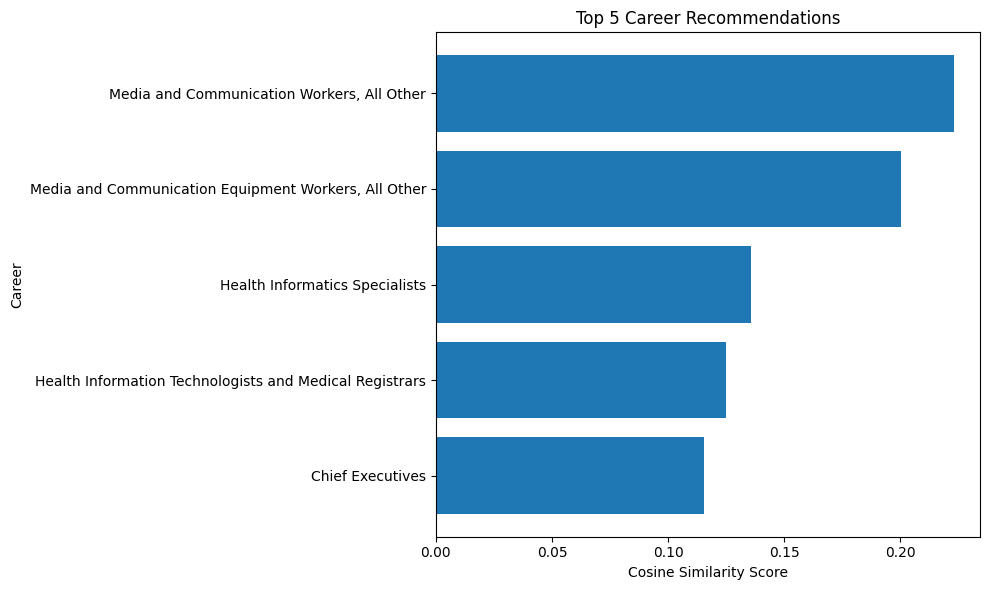

In [36]:
# TEST MODEL AND DISPLAY TOP 5 RECOMMENDATIONS

import matplotlib.pyplot as plt

# Test user profile
test_user = """
Education: Master's Degree.
Skills: leadership, critical thinking, communication,
problem solving, mathematics, planning, management,
training, and decision making.
Knowledge: administration, management, education,
technology, business, and personnel management.
Abilities: oral communication, written communication,
reasoning, analysis, and problem solving.
Work styles: leadership, initiative, responsibility,
achievement, and adaptability.
Experience: more than 10 years of professional
and management experience.
"""

# Convert user profile into TF-IDF representation
user_vector = tfidf_model.transform([test_user])

# Calculate similarity between user and every career
similarity_scores = cosine_similarity(
    user_vector,
    career_matrix
).flatten()

# Add scores to a temporary results dataframe
results_df = career_master_df[
    [
        "O*NET-SOC Code",
        "Title",
        "Description",
        "Education",
        "Experience"
    ]
].copy()

results_df["Similarity Score"] = similarity_scores

# Get top 5 recommendations
top_5 = (
    results_df
    .sort_values(
        "Similarity Score",
        ascending=False
    )
    .head(5)
    .reset_index(drop=True)
)

print("TOP 5 CAREER RECOMMENDATIONS")
print("=" * 60)

display(top_5)

# ------------------------------------------------------------
# CHART
# ------------------------------------------------------------

chart_data = top_5.sort_values(
    "Similarity Score",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    chart_data["Title"],
    chart_data["Similarity Score"]
)

plt.xlabel("Cosine Similarity Score")
plt.ylabel("Career")
plt.title("Top 5 Career Recommendations")

plt.tight_layout()
plt.show()

# Career Recommendation Model - Next Steps

## Current Status

The first version of the career recommendation model is complete.

The model currently:

1. Uses career information from the O*NET 31.0 database.
2. Combines occupation descriptions, skills, knowledge, abilities, work styles, education, and experience.
3. Uses TF-IDF to convert the career information into numerical features.
4. Uses cosine similarity to compare a user's profile against each O*NET occupation.
5. Returns the top five career recommendations.
6. Displays the recommendations in a bar chart.

The following files were created:

- `onet_career_master.csv`
- `career_tfidf_model.pkl`
- `career_tfidf_matrix.pkl`

---

## Next Step - Build the User Interface

The next step is to place the recommendation model into a simple user interface.

The interface should allow the user to enter:

- Education level
- Skills
- Interests
- Work experience
- Career goals or preferred career area
- Optional additional information

The application should combine these responses into a single user profile and send that profile to the TF-IDF recommendation model.

The application flow should be:

**User Input → User Profile → TF-IDF Transformation → Cosine Similarity → Top 5 Careers → Results**

The results should display:

- Career title
- O*NET-SOC code
- Career description
- Recommended education level
- Recommended experience level
- Similarity score

---

## Application Development

The interface can be developed using **Gradio** because it is lightweight, works with Python, and can later be deployed through Hugging Face Spaces.

The application will need to load:

```python
onet_career_master.csv
career_tfidf_model.pkl
career_tfidf_matrix.pkl